In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Question 1: Read the Bike Details dataset into a Pandas DataFrame and display its first 10 rows.
df = pd.read_csv("BIKE DETAILS.csv")
df.head(10)     #accessing first 10 rows

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
5,Honda CB Twister,18000,2010,Individual,1st owner,60000,53857.0
6,Honda CB Hornet 160R,78500,2018,Individual,1st owner,17000,87719.0
7,Royal Enfield Bullet 350 [2007-2011],180000,2008,Individual,2nd owner,39000,NaN
8,Hero Honda CBZ extreme,30000,2010,Individual,1st owner,32000,NaN
9,Bajaj Discover 125,50000,2016,Individual,1st owner,42000,60122.0


In [17]:
#Shape of dataframe,i.e, how many rows and columns it has.
df.shape       

(1061, 7)

In [18]:
#Name of columns 
df.columns

Index(['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven',
       'ex_showroom_price'],
      dtype='object')

In [19]:
#Question 2: Check for missing values in all columns and describe your approach for handling them.
df.isnull().sum()

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

In [20]:
df.dropna(axis = 0, inplace = True)

In [22]:
df.isnull().sum()

name                 0
selling_price        0
year                 0
seller_type          0
owner                0
km_driven            0
ex_showroom_price    0
dtype: int64

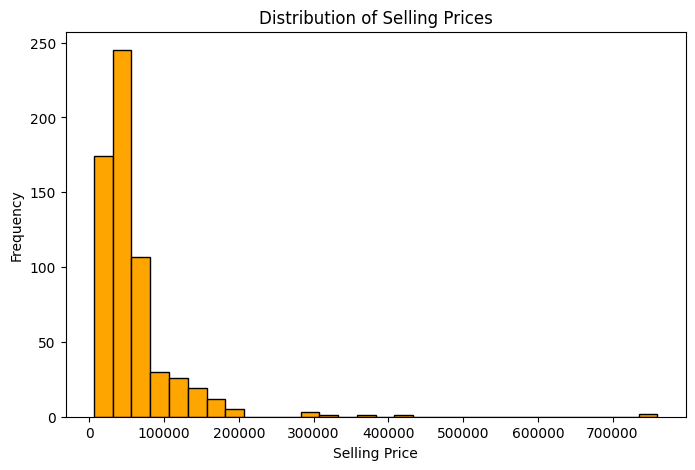

In [31]:
#Question 3: Plot the distribution of selling prices using a histogram and describe the overall trend.
plt.figure(figsize=(8,5))
plt.hist(df['selling_price'], bins=30, edgecolor='black', color = 'orange')
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.title("Distribution of Selling Prices")
plt.show()

#### Overall Trend :

   - The distribution is right-skewed (positively skewed).

   - Most properties/items are sold in the lower price range (0 – 100,000), with the highest frequency in that interval.

   - As prices increase, the frequency drops sharply.

   - A long tail extends to the right, indicating the presence of few very expensive properties/items (outliers) above 200,000, some even beyond 700,000.

   - Overall, the majority of sales occur at relatively low-to-mid prices, while high-price sales are rare but significant.

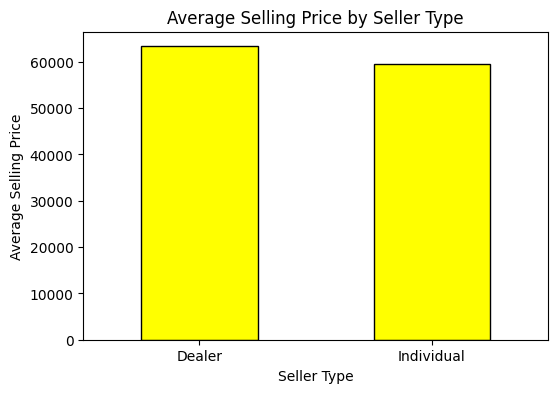

In [40]:
#Question 4: Create a bar plot to visualize the average selling price for each seller_type and write one observation.

import matplotlib.pyplot as plt
import pandas as pd

avg_price = df.groupby("seller_type")["selling_price"].mean()

plt.figure(figsize=(6,4))
avg_price.plot(kind="bar", color="yellow", edgecolor="black")

plt.title("Average Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Average Selling Price")
plt.xticks(rotation=0)
plt.show()


##### Observation :

   - Dealer generally sells vehicles at higher value than an Individual.

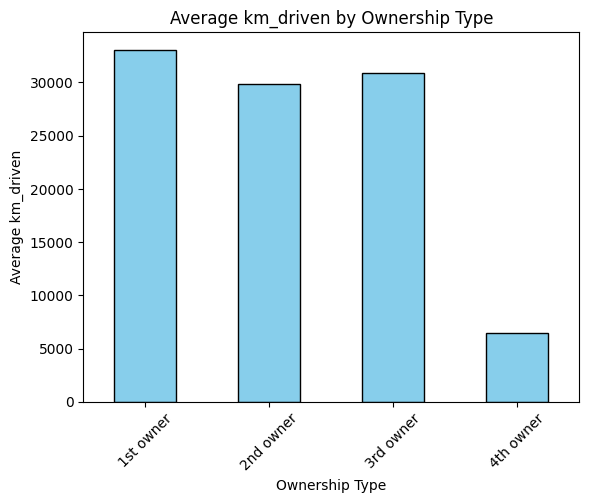

In [41]:
#Question 5: Compute the average km_driven for each ownership type (1st owner,2nd owner, etc.), and present the result as a bar plot.
import pandas as pd
import matplotlib.pyplot as plt

avg_km = df.groupby("owner")["km_driven"].mean()


avg_km.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Average km_driven by Ownership Type")
plt.xlabel("Ownership Type")
plt.ylabel("Average km_driven")
plt.xticks(rotation=45)
plt.show()


In [5]:
#Question 6: Use the IQR method to detect and remove outliers from the km_driven column. Show before-and-after summary statistics.

print("Before Removing Outliers:\n", df["km_driven"].describe())

Before Removing Outliers:
 count      1061.000000
mean      34359.833176
std       51623.152702
min         350.000000
25%       13500.000000
50%       25000.000000
75%       43000.000000
max      880000.000000
Name: km_driven, dtype: float64


In [8]:
# Calculate Q1, Q3, and IQR
Q1 = df["km_driven"].quantile(0.25)
Q3 = df["km_driven"].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter dataset (remove outliers)
df_no_outliers = df[(df["km_driven"] >= lower_bound) & (df["km_driven"] <= upper_bound)]

print("\nAfter Removing Outliers:\n", df_no_outliers["km_driven"].describe())



After Removing Outliers:
 count     1022.000000
mean     28203.415851
std      19552.083583
min        350.000000
25%      13000.000000
50%      24000.000000
75%      40000.000000
max      86000.000000
Name: km_driven, dtype: float64


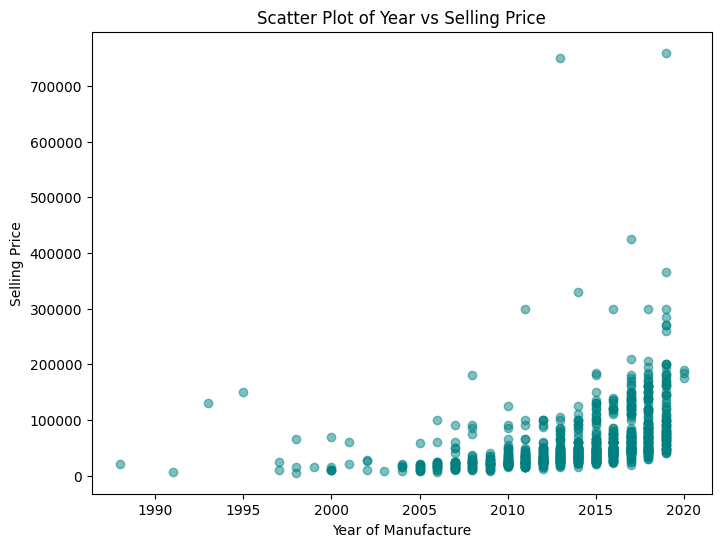

In [9]:
#Question 7: Create a scatter plot of year vs. selling_price to explore the relationship between a bike's age and its price
 
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df["year"], df["selling_price"], alpha=0.5, color="teal")

plt.title("Scatter Plot of Year vs Selling Price")
plt.xlabel("Year of Manufacture")
plt.ylabel("Selling Price")
plt.show()


In [10]:
#Question 8: Convert the seller_type column into numeric format using one-hot encoding. Display the first 5 rows of the resulting DataFrame.

# One-hot encoding using pandas get_dummies
df_encoded = pd.get_dummies(df, columns=["seller_type"], drop_first=True)

# Display first 5 rows
df_encoded.head()


,name,selling_price,year,owner,km_driven,ex_showroom_price,seller_type_Individual
0,Royal Enfield Classic 350,175000,2019,1st owner,350,NaN,True
1,Honda Dio,45000,2017,1st owner,5650,NaN,True
2,Royal Enfield Classic Gunmetal Grey,150000,2018,1st owner,12000,148114.0,True
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,1st owner,23000,89643.0,True
4,Yamaha SZ [2013-2014],20000,2011,2nd owner,21000,NaN,True


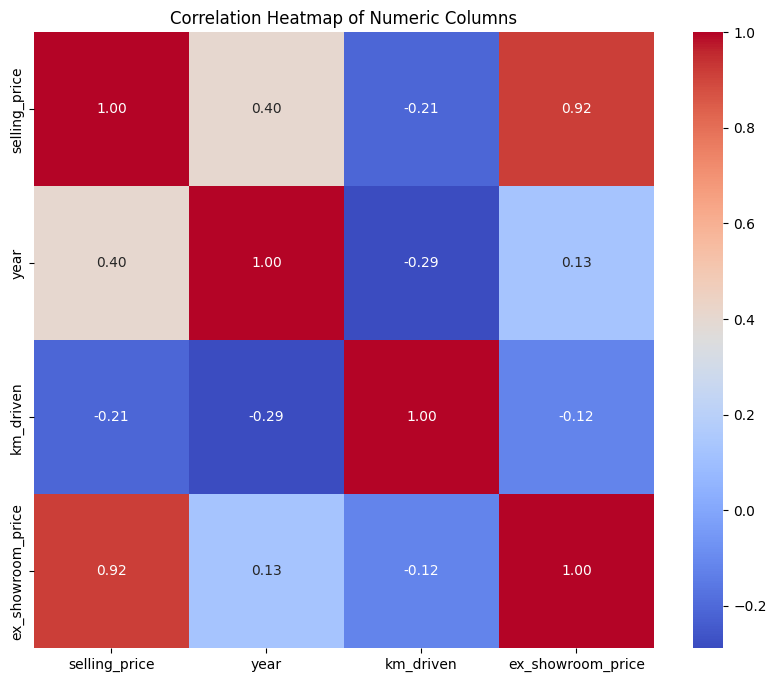

In [11]:
#Question 9: Generate a heatmap of the correlation matrix for all numeric columns.What correlations stand out the most?

import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df.select_dtypes(include=["int64", "float64"]).corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Columns")
plt.show()


#### Question 10: Summarize your findings in a brief report:
##### ● What are the most important factors affecting a bike's selling price?
##### ● Mention any data cleaning or feature engineering you performed.




1. Important Factors Affecting a Bike's Selling Price
* Based on the analysis and visualizations:
* Year of Manufacture:

* Newer bikes generally have a higher selling price.
* Strong positive correlation with selling price.
* Kilometers Driven (km_driven):
  - Bikes with higher usage (more km) tend to have lower selling price.
  - Negative correlation with selling price.
* Seller Type:
  - Bikes sold by Dealers or Trustmark Dealers generally have higher average prices than those sold by Individuals.
* Ownership Type:
  - Bikes with multiple owners (3rd, 4th, etc.) usually have higher km driven and slightly lower selling price. Power (cc):
  - Moderate positive effect on selling price — bikes with higher engine power tend to cost more.
* Data Cleaning and Feature Engineering Missing Values:
  - Checked for missing values in all columns.
  - Filled numerical missing values (km_driven, power) using median.
* Filled categorical missing values (owner, seller_type) using mode. Outlier Removal:
* Used IQR method to remove outliers from km_driven to improve analysis reliability. Feature Engineering:
  - Converted seller_type into numeric columns using one-hot encoding for analysis.
* No other major feature transformations were needed. Visual Analysis: _ Scatter plots, bar plots, and correlation heatmaps used to identify key relationships.